<a href="https://colab.research.google.com/github/asipnana/ProjectNLP/blob/main/notebooks/03_baseline_tfidf.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [26]:
!git clone https://github.com/asipnana/ProjectNLP.git

Cloning into 'ProjectNLP'...
remote: Enumerating objects: 212, done.
remote: Counting objects: 100% (75/75), done.
remote: Compressing objects: 100% (69/69), done.
remote: Total 212 (delta 34), reused 6 (delta 6), pack-reused 137 (from 1)
Receiving objects: 100% (212/212), 1.63 MiB | 6.49 MiB/s, done.
Resolving deltas: 100% (67/67), done.


In [27]:
%cd /content/ProjectNLP

/content/ProjectNLP


In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay)
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

In [29]:
train_df = pd.read_csv('/content/ProjectNLP/dataset/processed/train (2).csv')
test_df = pd.read_csv('/content/ProjectNLP/dataset/processed/test (2).csv')

In [30]:
train_df.head()

,review,sentiment,clean_review,sentiment_label
0,"kualitas barang bagus, dengan harga yg worth t...",Positive,kualitas barang bagus dengan harga yg worth th...,1
1,"Barang sesuai deskripsi, dan pengiriman tepat ...",Positive,barang sesuai deskripsi dan pengiriman tepat w...,1
2,KALI INI BELANJA DISINI SANGAT MENGECEWAKAN!!!...,Negative,kali ini belanja disini sangat mengecewakan fr...,0
3,.mas yg filter ini kok saya enga terima. Yg la...,Negative,mas yg filter ini kok saya enga terima yg lain...,0
4,Tidak seperti yg diperkirakan sebelumnya. Lebi...,Negative,tidak seperti yg diperkirakan sebelumnya lebih...,0


In [31]:
test_df.head()

,review,sentiment,clean_review,sentiment_label
0,"Mevvah bro , thx u fast respon dan fast delive...",Positive,mevvah bro thx u fast respon dan fast delivery...,1
1,nggak bisa jalan kereta nya.. anakqu jadi kecewa,Negative,nggak bisa jalan kereta nya anakqu jadi kecewa,0
2,Semuanya Manatttaapp gan Semoga sukses agan,Positive,semuanya manatttaapp gan semoga sukses agan,1
3,spray air tdk keluar embun,Negative,spray air tdk keluar embun,0
4,Beli 2 Ezviz C6N dan sudah terpasang dua-duany...,Positive,beli ezviz c n dan sudah terpasang dua duanya ...,1


In [32]:
X_train = train_df['clean_review']
y_train = train_df['sentiment_label']
X_test = test_df['clean_review']
y_test = test_df['sentiment_label']

In [33]:
tfidf = TfidfVectorizer(max_features=10000, ngram_range=(1,2))
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

In [34]:
print(X_train_tfidf.shape)
print(X_test_tfidf.shape)

(3713, 10000)
(796, 10000)


In [35]:
model_lr = LogisticRegression(
    max_iter=1000,
    random_state=42
)

model_lr.fit(
    X_train_tfidf,
    y_train
)

LogisticRegression(max_iter=1000, random_state=42)

In [36]:
y_pred = model_lr.predict(X_test_tfidf)

In [37]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.9321608040201005


In [38]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.91      0.97      0.94       413
           1       0.96      0.89      0.93       383

    accuracy                           0.93       796
   macro avg       0.94      0.93      0.93       796
weighted avg       0.93      0.93      0.93       796



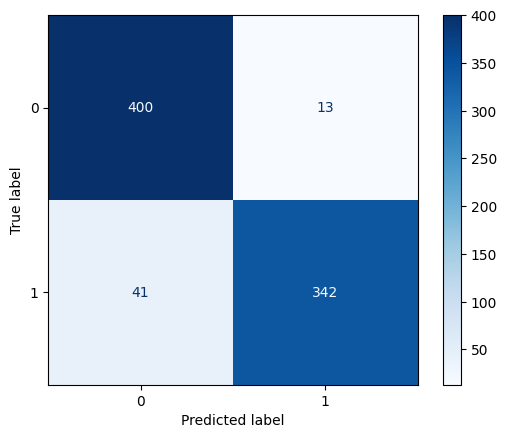

In [39]:
cm = confusion_matrix(y_test, y_pred)

display = ConfusionMatrixDisplay(confusion_matrix=cm)
display.plot(cmap='Blues')
plt.show()

In [40]:
results = pd.DataFrame({
    'Model': ['TF-IDF and Logistic Regression'],
    'Accuracy': [accuracy_score(y_test, y_pred)],
    'Precision': [precision_score(y_test, y_pred, average="weighted")],
    'Recall': [recall_score(y_test, y_pred, average="weighted")],
    'F1 Score': [f1_score(y_test, y_pred, average="weighted")]
})

results

,Model,Accuracy,Precision,Recall,F1 Score
0,TF-IDF and Logistic Regression,0.932161,0.934143,0.932161,0.931986


In [42]:
results.to_csv("/content/ProjectNLP/results/baseline_results.csv", index=False)

In [43]:
import joblib
import os

os.makedirs(
    "/content/ProjectNLP/models/tfidf_logreg",
    exist_ok=True
)

In [44]:
joblib.dump(
    tfidf,
    "/content/ProjectNLP/models/tfidf_logreg/tfidf.pkl"
)

['/content/ProjectNLP/models/tfidf_logreg/tfidf.pkl']

In [46]:
joblib.dump(
    model_lr,
    "/content/ProjectNLP/models/tfidf_logreg/logreg.pkl"
)

['/content/ProjectNLP/models/tfidf_logreg/logreg.pkl']